In [185]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

# Euler

In [186]:
S = [995]   # Number of susceptible individuals
I = [5]       # Number of infectious individuals
R = [0]       # Number of removed (and immune) or deceased individuals
N = [S[0] + I[0] + R[0]] 

# Parameters
beta = 0.5      # Infection rate
gamma = 0.3     # Recovery rate

# other
rng = np.random.default_rng(30)
iter_max = 65000

dt = 0.001
for t in range(iter_max):
    # Get Parameters 
    St = S[t]
    It = I[t]
    Rt = R[t]
    Nt = N[t]

    # Calculate derevative
    dSt = -beta/Nt * It * St
    dIt = beta/Nt * It * St - gamma * It
    dRt = gamma * It

    # Update 
    S.append(St+dSt*dt)
    I.append(It+dIt*dt)
    R.append(Rt+dRt*dt)
    N.append(St+dSt*dt+It+dIt*dt+Rt+dRt*dt)



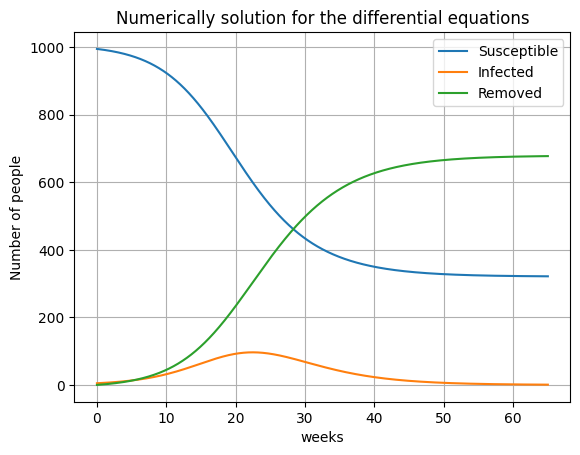

In [187]:
plt.plot(np.arange(0,(iter_max+1)*dt,dt),S,label="Susceptible")
plt.plot(np.arange(0,(iter_max+1)*dt,dt),I,label="Infected")
plt.plot(np.arange(0,(iter_max+1)*dt,dt),R,label="Removed")
plt.grid()
plt.title("Numerically solution for the differential equations")
plt.xlabel("weeks")
plt.ylabel("Number of people")
plt.legend()

In [188]:
print(f"I_max: {np.max(I)}")
print(f"E[R(inf)] = {R[-1]}")

I_max: 96.517259803516
E[R(inf)] = 677.5955531234044


# Simulation

In [189]:
def simple_sir(BETA, GAMMA, seed):
    S = [995]   # Number of susceptible individuals
    I = [5]       # Number of infectious individuals
    R = [0]       # Number of removed (and immune) or deceased individuals
    N = [S[0] + I[0] + R[0]] 
    T = [0]

    # Parameters
    beta = BETA       # Infection rate
    gamma = GAMMA     # Recovery rate

    # other
    rng = np.random.default_rng(seed)

    max_iter = 10_000

    iter = 0
    while True:
        # Get Parameters 
        St = S[iter]
        It = I[iter]
        Rt = R[iter]
        Nt = N[iter] 
        t = T[iter]

        # Calculate rate of infection and rate of recovery
        a1 = beta * St * It / Nt    # Rate of infection
        a2 = gamma * It             # Rate of recovery
        a0 = a1 + a2

        # Determine next time step
        dt = rng.exponential(1/a0)

        u = rng.uniform(size=1)
        if u < a1/a0:
            Stp1 = St - 1
            Itp1 = It + 1
            Rtp1 = Rt
        else:
            Stp1 = St
            Itp1 = It - 1
            Rtp1 = Rt + 1
        
        # Append
        S.append(Stp1)
        I.append(Itp1)
        R.append(Rtp1)
        N.append(Stp1 + Itp1 + Rtp1)
        T.append(t+dt)

        if Itp1 == 0 or iter == max_iter:
            break
        
        iter += 1
    
    return S,I,R,N,T

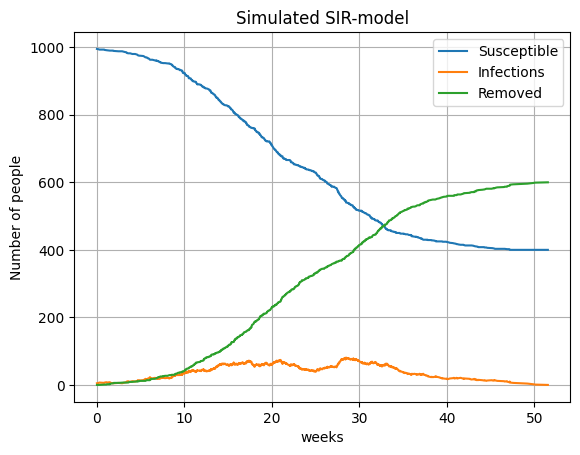

In [190]:
S,I,R,N,T = simple_sir(0.5, 0.3, seed=30)
plt.plot(T,S, label="Susceptible")
plt.plot(T,I, label="Infections")
plt.plot(T, R, label="Removed")
plt.grid()
plt.title("Simulated SIR-model")
plt.xlabel("weeks")
plt.ylabel("Number of people")
plt.legend()

Simulate 100 realisations

In [191]:
SS = []
II = []
RR = []
TT = []
for i in range(100):
    S,I,R,N,T = simple_sir(0.5, 0.3, seed=i)
    SS.append(S)
    II.append(I)
    RR.append(R)
    TT.append(T)

Estimate Time until the disease dies out $T_{max} = \inf\{t \geq 0 \vert I(t)=0\}$

In [225]:
T_MAX = np.empty(100)
for i in range(100):
    series = TT[i]
    T_MAX[i] = series[-1]

# Confidence interval
n = 100
alpha = 0.05
s = np.std(T_MAX, ddof=1)
x_bar = np.mean(T_MAX)
se = s/np.sqrt(n)
t_crit = ss.t.ppf(1 - alpha/2,df=n-1)


ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se


print(f"Time until the disease dies out {x_bar}")
print(f"std: {s}")
print(f"Confidence interval: {ci_lower}, {ci_upper}")
print(f"Confidence interval witdh: {ci_upper-ci_lower}")

Time until the disease dies out 60.38058021939242
std: 18.79534247666062
Confidence interval: 56.651176504086195, 64.10998393469865
Confidence interval witdh: 7.4588074306124525


Estimate peak $T_{peak}$

In [193]:
T_PEAK = np.empty(100)
for i in range(100):
    series = II[i]
    idx = np.argmax(series)
    T_PEAK[i] = TT[i][idx]

# Confidence interval
n = 100
alpha = 0.05
s = np.std(T_PEAK, ddof=1)
x_bar = np.mean(T_PEAK)
se = s/np.sqrt(n)
t_crit = ss.t.ppf(1 - alpha/2,df=n-1)


ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se

print(f"esitmated T_peak: {x_bar}")
print(f"std: {s}")
print(f"Confidence interval: {ci_lower}, {ci_upper}")
print(f"Confidence interval witdh: {ci_upper-ci_lower}")

esitmated T_peak: 22.749070258194987
std: 9.177867527851532
Confidence interval: 20.927982225377235, 24.57015829101274
Confidence interval witdh: 3.6421760656355033


Estimate $I_{max}/N$

In [224]:
I_MAX = np.empty(100)
for i in range(100):
    series = II[i]
    I_MAX[i] = np.max(series)
P_MAX = np.array(I_MAX) / 1000

# Confidence interval
n = 100
alpha = 0.05
s = np.std(P_MAX, ddof=1)
x_bar = np.mean(P_MAX)
se = s/np.sqrt(n)
t_crit = ss.t.ppf(1 - alpha/2,df=n-1)


ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se



print(f"esitmated T_peak: {x_bar}")
print(f"std: {s}")
print(f"Confidence interval: {ci_lower}, {ci_upper}")
print(f"Confidence interval witdh: {ci_upper-ci_lower}")

esitmated T_peak: 0.10274000000000001
std: 0.033716470812355265
Confidence interval: 0.09604992070664561, 0.10943007929335441
Confidence interval witdh: 0.013380158586708796


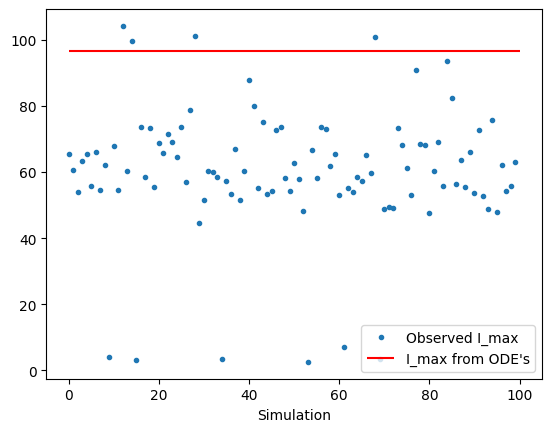

In [226]:
plt.plot(T_MAX, ".", label="Observed I_max")
plt.hlines(96.517,0,100, color="red", label="I_max from ODE's")
plt.xlabel("Simulation")
plt.legend()

In [229]:
test = np.array(T_MAX)
np.std(test[test >20], ddof=1)

np.float64(12.548188759446036)

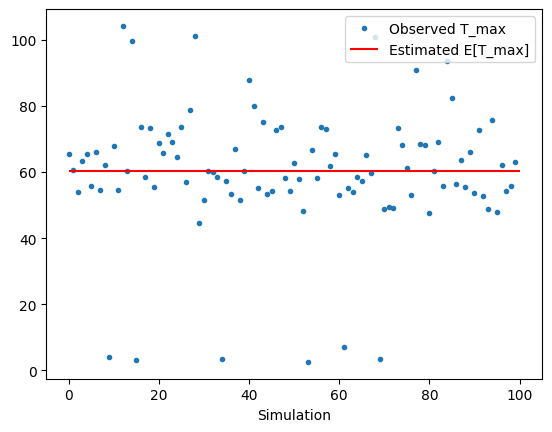

In [230]:
plt.plot(T_MAX, ".", label="Observed T_max")
plt.hlines(60.38 ,0,100, color="red", label="Estimated E[T_max]")
plt.xlabel("Simulation")
plt.legend(loc=1)

### Variance reduction

In [217]:
mu_z = 96.517    # From the deterministic solution right at the top
Control_variate = I_MAX
c = -np.cov(T_MAX, Control_variate)[0,1] / np.var(Control_variate, ddof=1)
Y = np.array(T_MAX) + c*(np.array(Control_variate) - mu_z)

In [218]:
np.mean(Y), np.std(Y, ddof=1)

(np.float64(59.1125745792942), np.float64(17.494757219920075))

In [219]:
np.corrcoef(T_MAX, Control_variate)

array([[1.        , 0.36552177],
       [0.36552177, 1.        ]])

In [220]:
c

np.float64(-0.20376115058625036)

In [221]:
# Confidence interval
n = 100
alpha = 0.05
s = np.std(Y, ddof=1)
x_bar = np.mean(Y)
se = s/np.sqrt(n)
t_crit = ss.t.ppf(1 - alpha/2,df=n-1)


ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se

print(ci_lower,ci_upper)
print(ci_upper-ci_lower)

55.64123519532877 62.583913963259626
6.9426787679308575


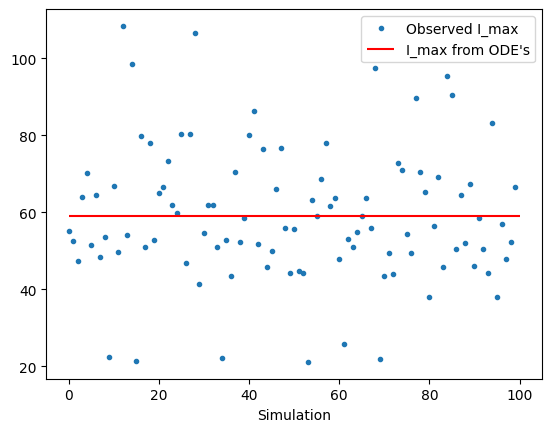

In [223]:
plt.plot(Y, ".", label="Observed I_max")
plt.hlines(59.11 ,0,100, color="red", label="I_max from ODE's")
plt.xlabel("Simulation")
plt.legend(loc=1)

### Variance reduction for T_peak

In [200]:
R_inf = np.empty(100)
for i in range(100):
    Ri = RR[i]
    R_inf[i] = Ri[-1]

# Confidence interval
n = 100
alpha = 0.05
s = np.std(R_inf, ddof=1)
x_bar = np.mean(R_inf)
se = s/np.sqrt(n)
t_crit = ss.t.ppf(1 - alpha/2,df=n-1)


ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se

print(f"esitmated T_peak: {x_bar}")
print(f"std: {s}")
print(f"Confidence interval: {ci_lower}, {ci_upper}")
print(f"Confidence interval witdh: {ci_upper-ci_lower}")

esitmated T_peak: 631.22
std: 166.0596570421898
Confidence interval: 598.2701613522261, 664.169838647774
Confidence interval witdh: 65.89967729554792


In [201]:
#mu_z = 96.517    # From the deterministic solution right at the top
mu_z = 677.5955531234044
Control_variate = R_inf
c = -np.cov(T_PEAK, Control_variate)[0,1] / np.var(Control_variate, ddof=1)
Y = np.array(T_PEAK) + c*(np.array(Control_variate) - mu_z)
print(np.mean(Y), np.std(Y, ddof=1))

24.097919569579325 7.8041836814995


In [202]:
np.corrcoef(T_PEAK, Control_variate)

array([[1.        , 0.52625554],
       [0.52625554, 1.        ]])

In [203]:
# Confidence interval
n = 100
alpha = 0.05
s = np.std(Y, ddof=1)
x_bar = np.mean(Y)
se = s/np.sqrt(n)
t_crit = ss.t.ppf(1 - alpha/2,df=n-1)


ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se

print(ci_lower,ci_upper)
print(ci_upper-ci_lower)

22.549400214166784 25.646438924991866
3.097038710825082


In [204]:
stop

NameError: name 'stop' is not defined

# Grid

In [ ]:
from scipy.signal import convolve2d

In [ ]:
rng = np.random.default_rng(40)

# Intitial 
n = 100
max_iter = 1_00
S = [np.ones((n,n), dtype=np.int8)]
I = [np.zeros_like(S[0])]
R = [np.zeros_like(S[0])]

# Insert initial infected
n_start = 3
init = rng.integers(low=0,high=n, size=(2,n_start))
I[0][*init] = 1
S[0][*init] = 0

# Convolve kernel
kernel = np.ones((3,3))
kernel[1,1] = 0

# Parameters
beta = 0.7      # Infection rate
gamma = 0.01     # Recovery rate

for t in range(max_iter-1):
    # Previous state
    St = S[t]
    It = I[t]
    Rt = R[t]
    infected_neighbors = convolve2d(It,kernel, mode="same", boundary="fill", fillvalue=0)

    St_new = np.copy(St)
    It_new = np.copy(It)
    Rt_new = np.copy(Rt)

    for i in range(n):
        for j in range(n):
            # Find out if we should infect or not
            if (infected_neighbors[i,j] > 0) and (St[i,j] == 1):
                infect = rng.binomial(n=infected_neighbors[i,j], p=beta)
                if (np.sum(infect) > 0):
                    St_new[i,j] = 0
                    It_new[i,j] = 1
                
            # Find out if person becomes immune
            if (It[i,j] == 1):
                recover = rng.binomial(n=1, p=gamma)
                if recover:
                    It_new[i,j] = 0
                    Rt_new[i,j] = 1
            

    # Append
    S.append(St_new)
    I.append(It_new)
    R.append(Rt_new)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

%matplotlib qt

# Define 3 distinct colors for values 0, 1, 2
colors = ['Blue', 'green', 'red']
cmap = mcolors.ListedColormap(colors)

fig, ax = plt.subplots()
img = ax.imshow(I[0] + 2*R[0], cmap=cmap, vmin=0, vmax=2)
cbar = fig.colorbar(img, ticks=[0, 1, 2])

for t in range(max_iter):
    im = I[t] + 2*R[t]
    img.set_data(im)
    plt.pause(0.1)